In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import re

In [3]:
lyrics = []
with open("song.json", "r", encoding="utf-8") as f:
    for line in f:
        if not line:
            continue
        tmp = json.loads(line)
        lyric_dirty = tmp.get("lyric")
        if lyric_dirty:
            lyric_dirty = lyric_dirty.strip()
            lyrics.append(lyric_dirty)
    

In [4]:
! pip install Counter 

In [5]:
! pip install jieba

In [6]:
! pip install wordcloud

In [7]:
from collections import Counter
import jieba

lyric_clean = []

for lyric_dirty in lyrics:
    lyric_split = lyric_dirty.split('\r\n')

    timestamp = False
    pattern = r"\[\d{2}:\d{2}.\d{2}\]"
    for block in lyric_split:
        if re.search("：", block) and not re.search(pattern, block):
            continue
        bly = re.sub(r'\[(ti|id|hash|total|ar|al|by|offset):.*?\]', '', block)
        lyric_clean.append(bly)

longstr = "".join(lyric_clean)

# \u4e00-\u9fa5 是汉字的 Unicode 范围
chinese = "".join(re.findall(r'[\u4e00-\u9fa5]', longstr))
chinese_list = jieba.lcut(chinese)
# \b[a-zA-Z]+\b 匹配完整的英文单词。这里顺便用 .lower() 统一转成小写
english = re.findall(r'\b[a-zA-Z]+\b', longstr.lower())

ignore_english = [
    # 冠词
    "a", "an", "the",
    # 代词
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", 
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", 
    "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
    "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are",
    # 介词
    "in", "out", "on", "off", "at", "by", "up", "down", "with", "for", "about", "against", 
    "between", "into", "through", "during", "before", "after", "above", "below", "to", 
    "from", "of", "over", "under", "again", "further", "then", "once",
    # 连词
    "and", "but", "or", "because", "as", "until", "while", "if", "so", "than",
    # 助动词及否定缩写
    "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", 
    "did", "doing", "can", "could", "should", "would", "will", "just", "don", "shouldn", 
    "now", "d", "ll", "m", "o", "re", "ve", "y", "ain", "aren", "couldn", "didn", "doesn", 
    "hadn", "hasn", "haven", "isn", "ma", "mightn", "mustn", "needn", "shan", "shouldn", 
    "wasn", "weren", "won", "wouldn",
    #other
    't', 's', 'ding', 'wanna', 'qq', 'all', 'dum', 'na', 'da', 'oh','get','got','gonna','yeah','oh',
    'when','no'
]

filtered_english_words = [word for word in english if word not in ignore_english]

en_counter = Counter(filtered_english_words)



Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\18041\AppData\Local\Temp\jieba.cache
Loading model cost 0.350 seconds.
Prefix dict has been built successfully.


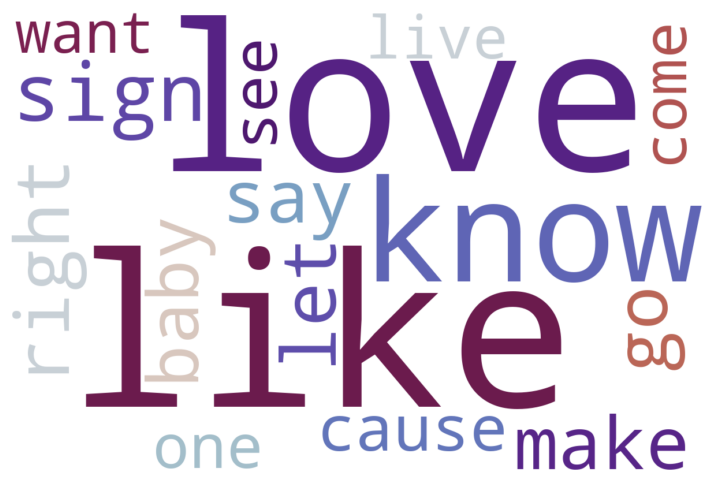

In [8]:
from wordcloud import WordCloud

en_word_counts = dict(en_counter.most_common(16))

wc = WordCloud(
    background_color="white",  # 背景颜色
    width=1200,                 # 图像宽度
    height=800,                # 图像高度
    max_words=100,             # 最多显示的词数
    colormap="twilight"         # 颜色主题（如 'viridis', 'plasma', 'inferno' 等）
)

wc.generate_from_frequencies(en_word_counts)

plt.figure(figsize=(10, 6))    # 设置画布大小
plt.imshow(wc, interpolation="bilinear") # 避免图像模糊
plt.axis("off")                # 隐藏坐标轴
plt.show()                     # 显示图片


In [9]:
ignore_chinese = [
    "真的", "地", "得", "了", "着", "过", "吧", "啊", "呢", "吗", "呀", "哦", "哈", "哇", "啦",
    "我会", "你", "他", "她", "它", "我们", "你们", "他们", "这", "那", "哪", "这个", "那个",
    "在", "从", "向", "往", "由", "于", "把", "不能", "让", "给", "为", "因", "对", "和", "跟", "与",
    "并", "并且", "而且", "而", "以及", "或者", "虽然", "但", "然而", "如果","不会", "有", "没有","到","制作","编曲",
    "个", "只是", "条", "件", "些", "一个", "一切", "还是", "又", "再", "就算", "才", "便", "作词", "混音","什么","多少","那么",
    "不是", "不会", "不要", "为了", "不再", "作曲" ,"怎么", "知道", "所有", "最后", "音乐","一起"
]
filtered_chinese_words = []

for word in chinese_list:
    word = word.strip()
    if word and len(word) > 1 and word not in ignore_chinese:
        filtered_chinese_words.append(word)

cn_counter = Counter(filtered_chinese_words)


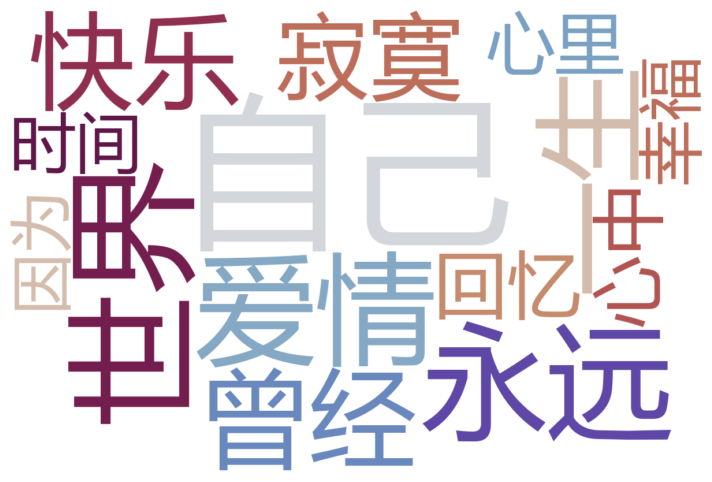

In [10]:
cn_word_counts = dict(cn_counter.most_common(14))

wc = WordCloud(
    font_path="msyh.ttc",      # 指定中文字体（Windows系统示例，Mac请换成PingFang.ttc）
    background_color="white",  # 背景颜色
    width=1200,                 # 图像宽度
    height=800,                # 图像高度
    max_words=100,             # 最多显示的词数
    colormap="twilight"         # 颜色主题（如 'viridis', 'plasma', 'inferno' 等）
)

wc.generate_from_frequencies(cn_word_counts)

plt.figure(figsize=(10, 6))    # 设置画布大小
plt.imshow(wc, interpolation="bilinear") # 避免图像模糊
plt.axis("off")                # 隐藏坐标轴
plt.show()                     # 显示图片


In [11]:
timelen = {}
with open("song2.json", "r", encoding="utf-8") as f:
    for line in f:
        length = json.loads(line).get("timelength")
        timelen[int(length // 100000)] = timelen.get(int(length // 100000),0) + 1


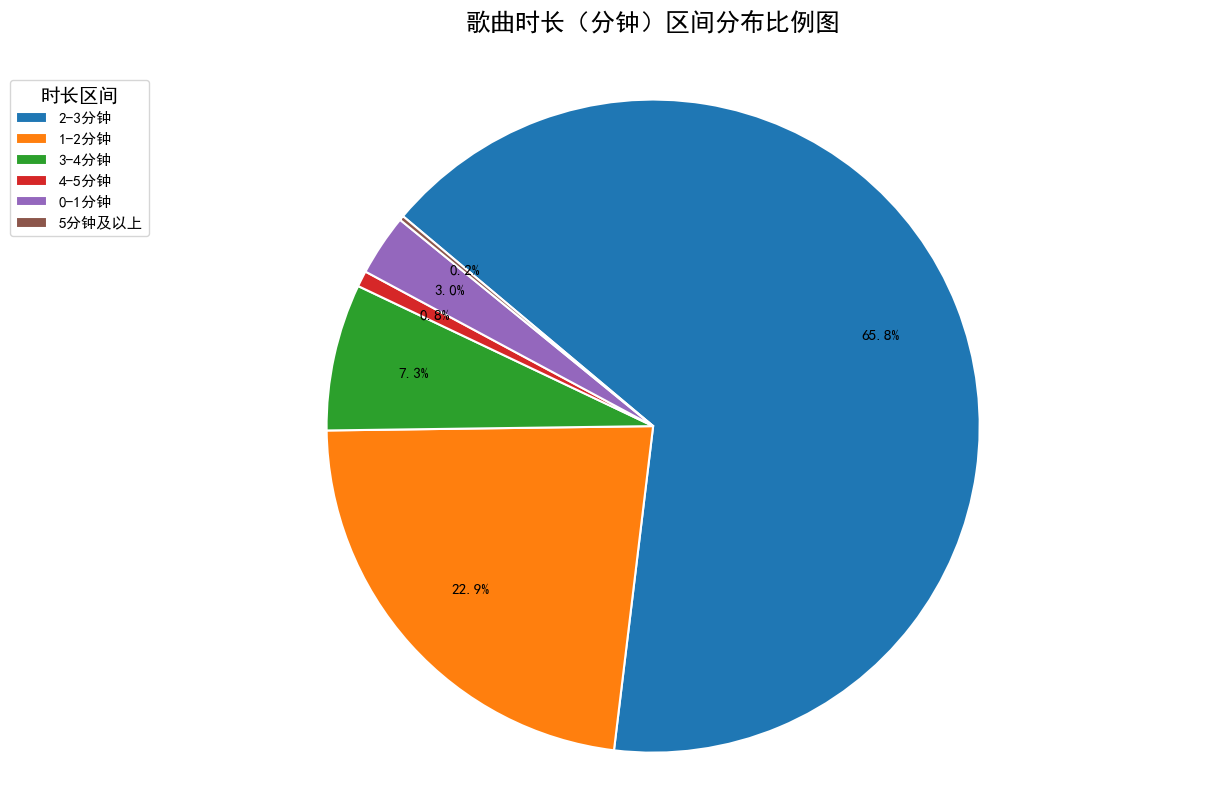

In [12]:
processed_timelen = {}
five_min_plus_count = 0

for k, v in timelen.items():
    if k >= 5:
        five_min_plus_count += v
    else:
        label = f"{k}-{k+1}分钟"
        processed_timelen[label] = v

if five_min_plus_count > 0:
    processed_timelen["5分钟及以上"] = five_min_plus_count

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

num_sectors = len(processed_timelen)
plt.figure(figsize=(12, 8), dpi=100)

wedges, texts, autotexts = plt.pie(
    processed_timelen.values(),
    
    autopct='%1.1f%%',             
    pctdistance=0.75,              
    startangle=140, 
    counterclock=False, 

    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.setp(autotexts, size=11, weight="bold", color="black")

plt.legend(
    wedges,                         
    processed_timelen.keys(),
    title="时长区间",
    loc="upper left",
    bbox_to_anchor=(-0.1, 1.0),
    fontsize=11, 
    title_fontsize=14
)

plt.title("歌曲时长（分钟）区间分布比例图", fontsize=18, fontweight='bold', pad=30)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [25]:
year = {}
month = {}
with open("release_time.json", "r", encoding="utf-8") as f:
    for line in f:
        if line is not None:
            rel = json.loads(line)

            data = rel.split('-')
            year[int(data[0])] = year.get(int(data[0]), 0) + 1
            month[int(data[1])] = month.get(int(data[1]), 0) + 1

year_sorted = {k : year[k] for k in sorted(year.keys())}
month_sorted = {k : month[k] for k in sorted(month.keys())}

del year_sorted[0]
del month_sorted[0]


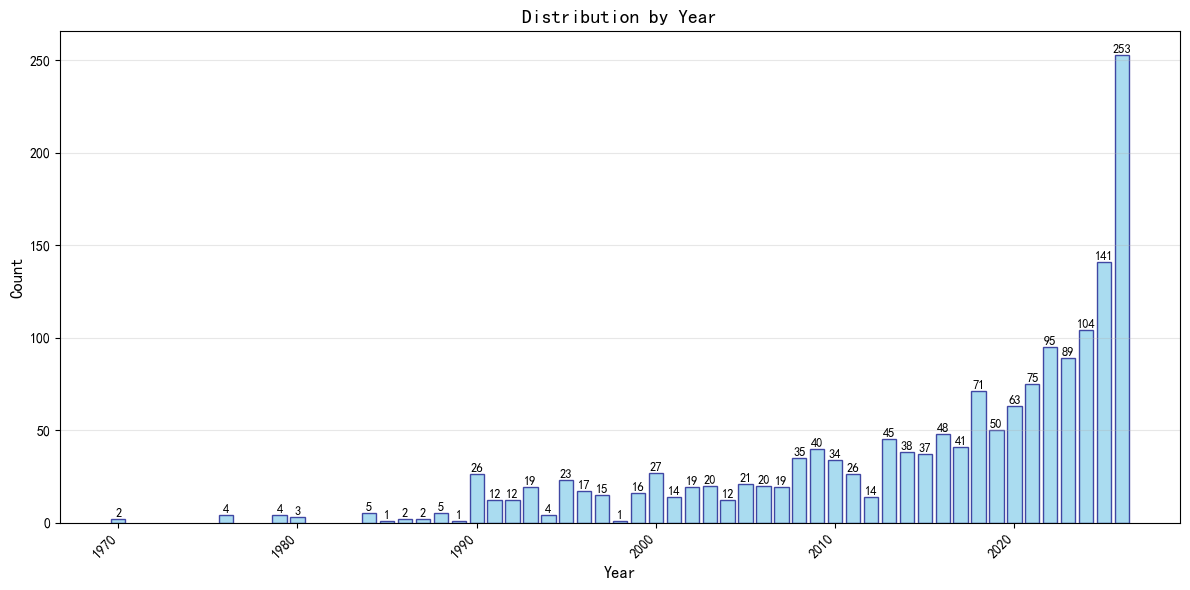

In [30]:
plt.figure(figsize=(12, 6))
years = list(year_sorted.keys())
values = list(year_sorted.values())

bars = plt.bar(years, values, color='skyblue', edgecolor='navy', alpha=0.7)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution by Year', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

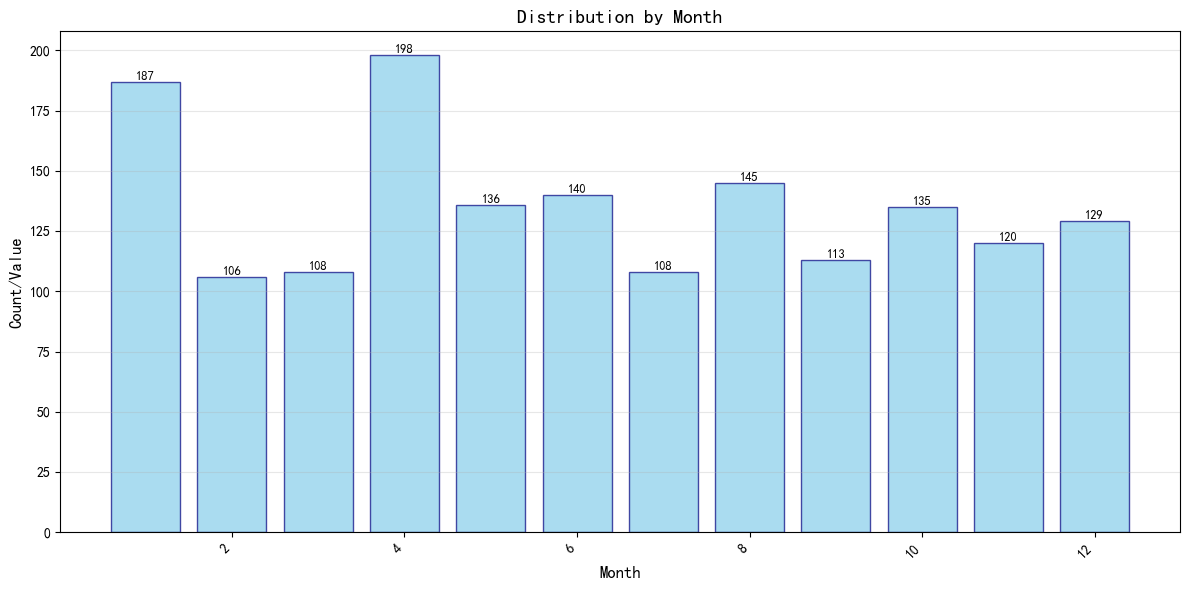

In [ ]:
plt.figure(figsize=(12, 6))
months = list(month_sorted.keys())
values = list(month_sorted.values())

bars = plt.bar(months, values, color='skyblue', edgecolor='navy', alpha=0.7)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution by Month', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()